In [39]:
import pandas as pd
import numpy as np
import json
import re
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt

In [40]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Collect runs

In [ ]:
# All run folders to include, relative to project root.
# Each entry is (folder_path, folder_tag) – tag appears in the DataFrame.
# PROJECT_ROOT = Path("/cephfs/home/bulatov/2026/autoresearch/compressing-associations-gdn")
PROJECT_ROOT = Path("/home/bulatov/rmt/test-time/compressing-associations-gdn")
RUNS_FOLDERS = [
    (PROJECT_ROOT / "runs-rmmv5",   "rmmv5"),
    (PROJECT_ROOT / "runs-rmmv5p",  "rmmv5p"),
    (PROJECT_ROOT / "runs-rmmv5p1", "rmmv5p1"),
    (PROJECT_ROOT / "runs-rmmv5p1-sweep-cap", "rmmv5p1"),
    (PROJECT_ROOT / "runs-rmmv5p2", "rmmv5p2"),
    (PROJECT_ROOT / "runs-rmmv5p2-sw", "rmmv5p2-sw"),
    (PROJECT_ROOT / "runs-rmmv5p3", "rmmv5p3"),
    (PROJECT_ROOT / "runs-rmmv5p4", "rmmv5p4"),
    (PROJECT_ROOT / "runs-rmmv5p5", "rmmv5p5"),
    (PROJECT_ROOT / "runs-rmmv5p7", "rmmv5p7"),
    (PROJECT_ROOT / "runs-rmmv6p0", "rmmv6p0"),
    (PROJECT_ROOT / "runs-rmmv6p1", "rmmv6p1"),
    (PROJECT_ROOT / "runs-rmmv6p2", "rmmv6p2"),
    (PROJECT_ROOT / "runs-rmmv6p4", "rmmv6p4"),
    # (PROJECT_ROOT / "runs-rmmv3",   "rmmv3"),
    (PROJECT_ROOT / "runs-baselines","segment_baselines"),
    (PROJECT_ROOT / "runs-rebuttal/rmmv5p7","rmmv5p7"),
    (PROJECT_ROOT / "runs-conv-study","conv_study"),

    # (Path("/home/bulatov/rmt/test-time/compressing-associations/runs-rebuttal-default"), "recurrent_baselines"),
    (Path("/home/bulatov/rmt/test-time/compressing-associations-gdn/runs-rebuttal-default"), "recurrent_baselines"),
]


def get_eval_from_trainer_state(run_path):
    """Fallback: read best-checkpoint eval metrics from trainer_state.json."""
    # Some runs have trainer_state.json directly in run_path (newer format)
    ts_path = run_path / 'trainer_state.json'
    if not ts_path.exists():
        # Older format: trainer_state lives inside the checkpoint subdirectory
        checkpoints = sorted(
            run_path.glob('checkpoint-*/trainer_state.json'),
            key=lambda p: int(p.parent.name.split('-')[1])
        )
        if checkpoints:
            ts_path = checkpoints[-1]
    if not ts_path.exists():
        return {}

    ts = json.load(open(ts_path))

    # Determine the best checkpoint step
    best_cpt = ts.get('best_model_checkpoint', '')
    m = re.search(r'checkpoint-(\d+)', best_cpt or '')
    best_step = int(m.group(1)) if m else None

    # Collect all log entries that have eval metrics
    eval_entries = [e for e in ts.get('log_history', []) if 'eval_exact_match' in e]
    if not eval_entries:
        return {}

    if best_step is not None:
        matching = [e for e in eval_entries if e.get('step') == best_step]
        entry = matching[0] if matching else eval_entries[-1]
    else:
        entry = eval_entries[-1]

    return {k: v for k, v in entry.items() if k.startswith('eval_')}


all_runs = []

for runs_path, folder_tag in RUNS_FOLDERS:
    if not runs_path.exists():
        print(f"Missing: {runs_path}")
        continue

    for run_path in sorted(runs_path.glob('**/run_*')):
        if not run_path.is_dir():
            continue
        if 'checkpoint' in str(run_path):
            continue

        stats = {}
        stats['folder_tag']  = folder_tag
        stats['run_path']    = str(run_path)
        stats['run_name']    = run_path.parent.name       # e.g. rmmv5_GatedDeltaNet_...
        stats['task_name']   = run_path.parent.parent.name  # e.g. N4-K2V2-V62_1M
        stats['run_id']      = int(run_path.name.split('_')[1])

        config_path = run_path / 'config.json'
        if config_path.exists():
            cli_args = json.load(open(config_path))['cli_args']
            stats.update(cli_args)

        results_path = run_path / 'all_results.json'
        if results_path.exists():
            results = json.load(open(results_path))
            stats.update(results)
        else:
            # Fallback: recover eval metrics from trainer_state.json
            fallback = get_eval_from_trainer_state(run_path)
            if fallback:
                stats.update(fallback)
                stats.setdefault('eval_exact_match',    np.nan)
                stats.setdefault('eval_token_accuracy', np.nan)
            else:
                stats['eval_exact_match']    = np.nan
                stats['eval_token_accuracy'] = np.nan

        all_runs.append(stats)

df = pd.DataFrame(all_runs)
print(f"Total runs: {len(df)}")
print(f"Columns: {list(df.columns)}")


Total runs: 2154
Columns: ['folder_tag', 'run_path', 'run_name', 'task_name', 'run_id', 'exp_path', 'per_device_batch_size', 'data_path', 'tokenizer_path', 'gradient_accumulation_steps', 'total_batch_size', 'metric_for_best_model', 'warmup_steps', 'max_steps', 'logging_steps', 'eval_steps', 'weight_decay', 'learning_rate', 'lr_scheduler_type', 'early_stopping_patience', 'seed', 'base_model', 'n_layer', 'n_head', 'n_embd', 'fla_layer', 'state_size', 'expand_v', 'conv_kernel', 'num_memory_vectors', 'write_mode', 'read_mode', 'write_value_dim', 'num_memory_heads', 'write_residual', 'memory_task_freq', 'memory_task', 'memory_key_size', 'memory_value_size', 'model_cpt', 'tokens_per_segment', 'n_pairs', 'n_keys', 'n_values', 'eval_exact_match', 'eval_exact_match_None', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'eval_token_accuracy', 'epoch', 'patience', 'use_orthogonal_rotation', 'use_sliding_window', 'use_parallel_prefill', 'use_short_conv', 'checkpoin

In [42]:
df.columns

Index(['folder_tag', 'run_path', 'run_name', 'task_name', 'run_id', 'exp_path',
       'per_device_batch_size', 'data_path', 'tokenizer_path',
       'gradient_accumulation_steps',
       ...
       'max_position_embeddings', 'max_input_length', 'overwrite_output_dir',
       'do_eval_only', 'binder_kind', 'binder_window', 'binder_n_heads',
       'binder_rank', 'num_input_tokens_seen', 'no_conv'],
      dtype='str', length=118)

In [43]:
df.eval_exact_match = df.eval_exact_match.fillna(df.eval_exact_match_base)

In [44]:
df.folder_tag.value_counts()

folder_tag
recurrent_baselines    816
rmmv5p4                325
rmmv5p7                283
rmmv5p1                192
segment_baselines      187
rmmv5p2                 79
rmmv6p2                 69
rmmv6p0                 53
rmmv5                   51
rmmv5p3                 32
rmmv5p2-sw              18
rmmv6p1                 14
rmmv6p4                 14
rmmv5p5                 10
conv_study               8
rmmv5p                   3
Name: count, dtype: int64

In [45]:
df.max_steps.value_counts()


max_steps
200000    1761
120000     144
10000      116
1           88
75000       17
5000        12
100000       7
30000        6
2000         2
80000        1
Name: count, dtype: int64

In [46]:
# def get_final_step(run_path: Path) -> float:
#     """Last global_step from trainer_state (run dir or latest checkpoint)."""
#     run_path = Path(run_path)
#     ts_path = run_path / "trainer_state.json"
#     if not ts_path.exists():
#         checkpoints = sorted(
#             run_path.glob("checkpoint-*/trainer_state.json"),
#             key=lambda p: int(p.parent.name.split("-")[1]),
#         )
#         if not checkpoints:
#             return np.nan
#         ts_path = checkpoints[-1]
#     ts = json.load(open(ts_path))
#     return ts.get("global_step", np.nan)
# df["final_step"] = df["run_path"].apply(lambda p: get_final_step(Path(p)))
# df["completed"] = df["final_step"] >= df["max_steps"]
# EM_THRESH = 0.90  # eval_exact_match is 0–1 in df, not percent
# df = df[
#     df["completed"]
#     | (df["eval_exact_match"] >= EM_THRESH)
# ].copy()

# # df["has_all_results"] = df["run_path"].apply(
# #     lambda p: (Path(p) / "all_results.json").exists()
# # )

# # # strict: only runs that finished the script
# # df_finished = df[df["has_all_results"]]

# # # or combine with your 90% rule for fallback-only high performers
# # df_ok = df[
# #     df["has_all_results"]
# #     | (df["eval_exact_match"] >= 0.90)  # rescue intentional / lucky early peaks
# # ]

# # # if you add best_step when collecting (from checkpoint-N in best_model_checkpoint)
# # df_ok = df[
# #     (df["final_step"] >= df["max_steps"])
# #     | (df["eval_exact_match"] >= 0.90)
# # ]

# df.shape

## Parse / normalise columns

In [47]:
# ── Parse version tag and a few fields not guaranteed to be in cli_args ─────

def parse_run_name(run_name: str) -> dict:
    """
    Extract structured parameters from a run-name string.

    Run-name patterns
    -----------------
    rmmv5 / rmmv5p / rmmv5p1:
      {version}_{FLA}_{base}_L{L}H{H}D{D}
          _ss{ss}_M{M}_{read}[H{nmh}]_{write}[-md{wvd}|-wvd{wvd}]
          _lr{lr}_bs{bs}[_pps{pps}][_tps{tps}]

    rmmv3:
      {version}_{FLA}_{base}_L{L}H{H}D{D}
          _ss{ss}_M{M}_{mode}     <- single mode = both read & write
          _lr{lr}_bs{bs}_pps{pps}

    segment_baselines (armt / rmt):
      {version}_{base}_L{L}H{H}D{D}_mem{nmem}[d{dmem}]_lr{lr}[-{nc}x{np}]_bs{bs}[-gen]

    recurrent_baselines (gated_delta_net / mamba / mamba2):
      {model}_L{L}D{D}_ss{ss}[_ck{ck}|_noconv]_bs_{bs}_lr_{lr}_b2_{b2}
    """
    info = {}

    # Version / model family
    # Order matters: mamba2 before mamba, gated_delta_net before others
    m = re.match(r'^(rmmv\d+(?:p\d*)?|armt|rmt|gated_delta_net|mamba2?)', run_name)
    if m:
        info['version'] = m.group(1)

    # Architecture dimensions: L, H, D  (H is optional in recurrent_baselines)
    m = re.search(r'_L(\d+)H(\d+)D(\d+)', run_name)
    if m:
        info['L'] = int(m.group(1))
        info['H'] = int(m.group(2))
        info['D'] = int(m.group(3))
    else:
        # Fallback: L{L}D{D} without H (recurrent_baselines naming)
        m = re.search(r'_L(\d+)D(\d+)', run_name)
        if m:
            info['L'] = int(m.group(1))
            info['D'] = int(m.group(2))

    # state_size  (_ss{N})
    m = re.search(r'_ss(\d+)', run_name)
    if m:
        info['ss_parsed'] = int(m.group(1))

    # num_memory_vectors  (_M{N}_)
    m = re.search(r'_M(\d+)_', run_name)
    if m:
        info['M_parsed'] = int(m.group(1))

    # n_mem_tokens for segment_baselines  (_mem{N})
    m = re.search(r'_mem(\d+)', run_name)
    if m:
        info['mem_parsed'] = int(m.group(1))

    # write_value_dim  (-md{N}  or  -wvd{N})
    m = re.search(r'-(?:md|wvd)(\d+)', run_name)
    if m:
        info['write_value_dim_parsed'] = int(m.group(1))

    # conv_kernel  (_ck{N}) – present in recurrent_baselines and rmmv5p1
    m = re.search(r'_ck(\d+)', run_name)
    if m:
        info['ck_parsed'] = int(m.group(1))

    # pairs_per_segment (_pps{N})
    m = re.search(r'_pps(\d+)', run_name)
    if m:
        info['pps_parsed'] = int(m.group(1))

    # tokens_per_segment (_tps{N})
    m = re.search(r'_tps(\d+)', run_name)
    if m:
        info['tps_parsed'] = int(m.group(1))

    # Read/write mode from name (fallback for runs where config.json is absent)
    # Known modes: unpool, pool, cross_attn, identity
    _M = r'(unpool|pool|cross_attn|identity)'

    # Two-mode: _M{N}_{read}[H\d+]_{write}[-md/wvd{N}] followed by _ev/_ck/_lr/_bs
    two = re.search(
        r'_M\d+_' + _M + r'(?:H\d+)?_' + _M + r'(?:-(?:md|wvd)\d+)?(?=_(?:ev|ck|lr|bs))',
        run_name
    )
    if two:
        info['read_mode_parsed']  = two.group(1)
        info['write_mode_parsed'] = two.group(2)
    else:
        # Single-mode (rmmv3): _M{N}_{mode}_lr
        one = re.search(r'_M\d+_' + _M + r'_lr', run_name)
        if one:
            info['read_mode_parsed']  = one.group(1)
            info['write_mode_parsed'] = one.group(1)

    return info


parsed = df['run_name'].apply(parse_run_name).apply(pd.Series)
df = pd.concat([df, parsed], axis=1)


In [48]:
# ── Unified column names across all model families ────────────────────────

# state_size: prefer cli_args value; fall back to parsed
if 'state_size' not in df.columns:
    df['state_size'] = np.nan
df['state_size'] = df['state_size'].fillna(df.get('ss_parsed'))

# num_memory_vectors: cli_args > M_parsed; segment_baselines use n_mem_tokens
if 'num_memory_vectors' not in df.columns:
    df['num_memory_vectors'] = np.nan
df['num_memory_vectors'] = df['num_memory_vectors'].fillna(df.get('M_parsed'))
if 'n_mem_tokens' in df.columns:
    df['num_memory_vectors'] = df['num_memory_vectors'].fillna(df['n_mem_tokens'])

# write_value_dim: prefer cli_args; fall back to name-parsed
if 'write_value_dim' not in df.columns:
    df['write_value_dim'] = np.nan
df['write_value_dim'] = df['write_value_dim'].fillna(df.get('write_value_dim_parsed'))

# read_mode / write_mode: fill NaN with name-parsed, then 'N/A' for baselines
for col in ['read_mode', 'write_mode', 'fla_layer']:
    if col not in df.columns:
        df[col] = np.nan

# Prefer cli_args value; fall back to what was parsed from the run name
if 'read_mode_parsed' in df.columns:
    df['read_mode'] = df['read_mode'].fillna(df['read_mode_parsed'])
if 'write_mode_parsed' in df.columns:
    df['write_mode'] = df['write_mode'].fillna(df['write_mode_parsed'])

# rmmv3 uses a single mode for both read and write; only write_mode is in config
rmmv3_mask = (
    (df['folder_tag'] == 'rmmv3')
    & df['read_mode'].isna()
    & df['write_mode'].notna()
)
df.loc[rmmv3_mask, 'read_mode'] = df.loc[rmmv3_mask, 'write_mode']

# Final fill: 'N/A' for any remaining NaN
for col in ['read_mode', 'write_mode', 'fla_layer']:
    df[col] = df[col].fillna('N/A')

# tokens_per_segment: prefer cli_args
if 'tokens_per_segment' not in df.columns:
    df['tokens_per_segment'] = np.nan
df['tokens_per_segment'] = df['tokens_per_segment'].fillna(df.get('tps_parsed'))

# pairs_per_segment: prefer cli_args
if 'pairs_per_segment' not in df.columns:
    df['pairs_per_segment'] = np.nan
df['pairs_per_segment'] = df['pairs_per_segment'].fillna(df.get('pps_parsed'))

# n_pairs from task_name
df['n_pairs_task'] = df['task_name'].str.extract(r'^N(\d+)-').astype(float)

# Convenience label: write_mode / write_value_dim combined
df['write_config'] = df['write_mode'].astype(str)
mask_md = df['write_value_dim'].notna()
df.loc[mask_md, 'write_config'] = (
    df.loc[mask_md, 'write_mode'].astype(str) + '-md' +
    df.loc[mask_md, 'write_value_dim'].astype(int).astype(str)
)

# Short label for legend: folder_tag + read_mode + write_config
df['config_label'] = (
    df['folder_tag'] + '|' +
    df['read_mode'].astype(str) + '→' +
    df['write_config'].astype(str)
)

df.shape


(2154, 134)

In [49]:
df.loc[df.use_short_conv == False, 'conv_kernel'] = 0

In [50]:
def get_pps_from_tps(tps):
    if tps == 32:
        return 4
    else:
        return round(tps/7)

df.loc[df.pairs_per_segment == 0, 'pairs_per_segment'] = df.loc[df.pairs_per_segment == 0, 'tokens_per_segment'].apply(get_pps_from_tps)

## Groupby table

In [51]:
# Effective conv kernel: 0 = no conv, else the actual kernel size
df['conv_type'] = df.apply(
    lambda r: 'noconv' if r.get('no_conv') is True
            else (f"ck{int(r['conv_kernel'])}" if pd.notna(r.get('conv_kernel')) else 'N/A'),
    axis=1
)

In [52]:
for col in ["num_memory_vectors", "pairs_per_segment"]:
    df[col] = df[col].fillna(-1).astype(int)

In [53]:
df_valid = df.dropna(subset=['eval_exact_match']).copy()

# df_valid = df_valid[df_valid['write_config'] == 'identity']

GROUP_COLS = [
    'task_name',
    'folder_tag',
    'base_model',
    'n_layer',
    'n_head',
    'n_embd',
    'state_size',
    # 'conv_kernel',
    'conv_type',
    'num_memory_vectors',
    'read_mode',
    'write_config',
    # 'tokens_per_segment',
    'pairs_per_segment',
    'learning_rate',
]

# Drop group cols that are entirely NaN / not in df
GROUP_COLS = [c for c in GROUP_COLS if c in df_valid.columns and df_valid[c].notna().any()]

grouped = df_valid.groupby(GROUP_COLS, dropna=False).agg(
    avg_em  = ('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em  = ('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems = ('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs  = ('eval_exact_match', 'count'),
)

# Sort by task n_pairs then avg_em descending
gr = grouped.copy()
gr['_n_pairs_sort'] = gr.index.get_level_values('task_name').str.extract(r'^N(\d+)-').astype(float).values
gr = gr.sort_values(['_n_pairs_sort', 'avg_em'], ascending=[True, False]).drop(columns='_n_pairs_sort')
# gr already has GROUP_COLS as index; no need to set_index again
grouped

avg_em  \
task_name                                          folder_tag          base_model      n_layer n_head n_embd state_size conv_type num_memory_vectors read_mode  write_config     pairs_per_segment learning_rate           
N16-K2V2-V62_1M                                    conv_study          gated_delta_net 4       4      128    16.0       N/A       -1                 N/A        N/A              -1                0.00100          0.60   
                                                   recurrent_baselines gated_delta_net 1       1      64     4.0        ck2       -1                 N/A        N/A              -1                0.00100          0.74   
                                                                                                                        ck4       -1                 N/A        N/A              -1                0.00100          0.55   
                                                                                       4       1      128    16.0       ck2       -1                 N/A        N/A              -1                0.00100         56.03   
                                                                                                                        ck4       -1                 N/A        N/A              -1                0.00100         61.60   
                                                                                               4      128    16.0       noconv    -1                 N/A        N/A              -1                0.00030          2.77   
                                                                                                                                                                                                   0.00100          0.17   
                                                                       mamba           4       1      128    8.0        ck4       -1                 N/A        N/A              -1                0.00030         94.46   
                                                                                                                                                                                                   0.00100         96.29   
                                                                                                             16.0       ck2       -1                 N/A        N/A              -1                0.00100         98.69   
                                                                                                                        ck4       -1                 N/A        N/A              -1                0.00100         98.74   
                                                                                                             32.0       ck4       -1                 N/A        N/A              -1                0.00030         55.59   
                                                                                                                                                                                                   0.00100         55.61   
                                                                                               4      128    16.0       noconv    -1                 N/A        N/A              -1                0.00030         87.44   
                                                                                                                                                                                                   0.00100          0.13   
                                                                       mamba2          1       1      64     4.0        ck2       -1                 N/A        N/A              -1                0.00100          4.17   
                                                                                                                        ck4       -1                 N/A        N/A              -1                0.00100         23.53   
                              

In [54]:
# grouped.to_csv("grouped.csv")

### Cross-architecture comp

In [55]:
df_valid = df.dropna(subset=['eval_exact_match']).copy()

select_tasks = [
                "N32-K2V2-V62_1M", 
                "N16-K2V2-V62_1M", 
                "N8-K2V2-V62_1M",
                "N4-K2V2-V62_1M",
]
df_valid = df_valid[df_valid['task_name'].isin(select_tasks)]

df_valid = df_valid[df_valid['n_layer'] == 4]
df_valid = df_valid[df_valid['n_embd'] == 128]

# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p1', 'rmmv5p2', 'rmmv5p2-sw', 'segment_baselines', 'recurrent_baselines', 'conv_study']
# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p1', 'rmmv5p2', 'rmmv5p2-sw', 'rmmv5p4', 'rmmv5p5', 'segment_baselines', 'recurrent_baselines', 'conv_study']
# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p1', 'rmmv5p2', 'rmmv5p2-sw', 'rmmv5p4', 'segment_baselines']
# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p1', 'rmmv5p2', 'rmmv5p2-sw']
# select_tags = ['segment_baselines']
# select_tags = ['recurrent_baselines']
# select_tags = ['conv_study']
# select_tags = ['rmmv5p4', 'rmmv5p5', 'rmmv5p6', 'segment_baselines', 'recurrent_baselines']
# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p1', 'rmmv5p2', 'rmmv5p4', 'rmmv5p5', 'rmmv5p6', 'segment_baselines', 'recurrent_baselines']
# select_tags = ['rmmv5p4', 'rmmv5p5', 'rmmv5p6', 'rmmv5p7', 'segment_baselines', 'recurrent_baselines']
# select_tags = ['rmmv5p4', 'rmmv5p7', 'rmmv6p0', 'rmmv6p1', 'rmmv6p2', 'rmmv6p4']
select_tags = ['rmmv5p4', 'rmmv5p7']
# select_tags = ['rmmv5p4']
df_valid = df_valid[df_valid['folder_tag'].isin(select_tags)]




GROUP_COLS = [
    'task_name',
    'pairs_per_segment',
    'folder_tag',
    'base_model',
    'n_head',
    'state_size',
    # 'conv_kernel',
    'conv_type',
    'num_memory_vectors',
    'd_mem',
    'read_mode',
    'write_config',
    # 'tokens_per_segment',
    'learning_rate',
]

# Drop group cols that are entirely NaN / not in df
GROUP_COLS = [c for c in GROUP_COLS if c in df_valid.columns and df_valid[c].notna().any()]

grouped = df_valid.groupby(GROUP_COLS, dropna=False).agg(
    avg_em  = ('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em  = ('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems = ('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs  = ('eval_exact_match', 'count'),
)

# Sort by task n_pairs then avg_em descending
gr = grouped.copy()
gr['_n_pairs_sort'] = gr.index.get_level_values('task_name').str.extract(r'^N(\d+)-').astype(float).values
gr = gr.sort_values(['_n_pairs_sort', 'avg_em'], ascending=[True, False]).drop(columns='_n_pairs_sort')
# gr already has GROUP_COLS as index; no need to set_index again
grouped

avg_em  \
task_name       pairs_per_segment folder_tag base_model n_head state_size conv_type num_memory_vectors read_mode write_config learning_rate           
N16-K2V2-V62_1M 1                 rmmv5p4    llama      1      32.0       ck4       1                  unpool    pool         0.00010          1.36   
                                                                                                                              0.00030          0.20   
                                                                                                                              0.00100          0.02   
                                                                                    2                  unpool    pool         0.00010         10.60   
                                                                                                                              0.00030          0.12   
                                                                                                                              0.00100          0.02   
                                                                                    8                  unpool    pool         0.00001          0.87   
                                                                                                                              0.00005          4.72   
                                                                                                                              0.00010         55.08   
                                                                                                                              0.00030          2.90   
                                                                                    32                 unpool    pool         0.00001          0.43   
                                                                                                                              0.00005         23.30   
                                                                                                                              0.00010          7.89   
                                                                                                                              0.00030          2.85   
                                                        4      32.0       ck4       4                  unpool    pool         0.00010          5.41   
                                                                                                                              0.00030          1.83   
                                                                                                                              0.00100          0.02   
                                                                                    8                  unpool    pool         0.00010          9.23   
                                                                                                                              0.00030          0.24   
                                                                                                                              0.00100          0.01   
                                                                                    32                 unpool    pool         0.00010          8.50   
                                                                                                                              0.00030          3.11   
                                                                                    64                 unpool    pool         0.00010          2.78   
                                                                                                                              0.00030          0.50   
                2                 rmmv5p4    llama      1      32.0       ck4       8                  unpool    pool         0.00001          0.81   
                                                                

In [56]:
1/0

ZeroDivisionError: division by zero

### selected

In [ ]:
# # dict(zip(df_valid.folder_tag.unique(), df_valid.folder_tag.unique()))
# fp2model = {'rmmv5p2': 'rmm',
#  'rmmv5p2-sw': 'rmm-sw',
#  'rmmv5p1': 'rmm-v0',
#  'rmmv5': 'rmm-v0',
#  'segment_baselines': 'segment_baselines',
#  'recurrent_baselines': 'recurrent_baselines'}

In [ ]:
df = df[~df['task_name'].isin({'babilong_qa1_0k', 'babilong_qa2_0k', 'babilong_qa3_0k', 'babilong_qa4_0k', 'babilong_qa5_0k', 'squad-short'})]

In [ ]:
df['model_tag'] = df['folder_tag']
df.loc[df['folder_tag'] == 'segment_baselines', 'model_tag'] = df[df['folder_tag'] == 'segment_baselines'].apply(lambda row: 'armt' if not pd.isna(row.d_mem) else 'rmt', axis=1)
df.loc[df['folder_tag'] == 'recurrent_baselines', 'model_tag'] = df[df['folder_tag'] == 'recurrent_baselines'].base_model
# df.loc[df['folder_tag'] == 'recurrent_baselines', 'model_tag'] = df[df['folder_tag'] == 'recurrent_baselines'].base_model


df['n_pairs'] = df['task_name'].str.extract(r'^N(\d+)-').astype(int)

In [ ]:
df_valid = df.dropna(subset=['eval_exact_match']).copy()

select_tasks = [
                "N4-K2V2-V62_1M",
                "N8-K2V2-V62_1M",
                "N16-K2V2-V62_1M",
                "N32-K2V2-V62_1M",
]
df_valid = df_valid[df_valid['task_name'].isin(select_tasks)]

df_valid = df_valid[df_valid['n_layer'] == 4]
df_valid = df_valid[df_valid['n_embd'] == 128]

# df_valid = df_valid[df_valid['state_size'] != ]

# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p1', 'rmmv5p2', 'rmmv5p2-sw', 'rmmv5p4', 'rmmv5p5', 'segment_baselines', 'recurrent_baselines']
# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p2', 'rmmv5p2-sw', 'segment_baselines', 'recurrent_baselines']
# select_tags = ['rmmv5p4', 'rmmv5p5', 'rmmv5p6', 'segment_baselines', 'recurrent_baselines']
# select_tags = ['rmmv5p4', 'rmmv5p5', 'rmmv5p6', 'rmmv5p7']
select_tags = ['rmmv6p0', 'rmmv6p1', 'rmmv6p2']
# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p1', 'rmmv5p2', 'rmmv5p2-sw']
# select_tags = ['segment_baselines']
# select_tags = ['recurrent_baselines']
df_valid = df_valid[df_valid['folder_tag'].isin(select_tags)]
# df_valid['tag'] = df_valid.folder_tag.apply(lambda x: fp2model[x])

GROUP_COLS = [
    # 'task_name',
    'n_pairs',
    # 'tag',
    # "folder_tag",
    'pairs_per_segment',
    "model_tag",
    # 'base_model',
    'state_size',
    "n_head",

    'conv_type',
    'num_memory_vectors',
    # 'd_mem',
    'read_mode',
    'write_config',
    # 'tokens_per_segment',
    'learning_rate',
    # 'd_mem',
    

]

# Drop group cols that are entirely NaN / not in df
GROUP_COLS = [c for c in GROUP_COLS if c in df_valid.columns and df_valid[c].notna().any()]

grouped = df_valid.groupby(GROUP_COLS, dropna=False).agg(
    avg_em  = ('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em  = ('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems = ('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs  = ('eval_exact_match', 'count'),
)

# Sort by task n_pairs then avg_em descending
gr = grouped.copy()
# gr['_n_pairs_sort'] = gr.index.get_level_values('n_pairs').str.extract(r'^N(\d+)-').astype(float).values
gr = gr.sort_values(['n_pairs', 'avg_em'], ascending=[True, False])#.drop(columns='n_pairs')
# gr already has GROUP_COLS as index; no need to set_index again
# grouped

In [ ]:
KEY_COLS = [
    'n_pairs',
    'pairs_per_segment',
    'model_tag',   # or 'folder_tag'
    'num_memory_vectors',
    'read_mode',
    'write_config',
    # 'd_mem',
    # 'state_size',
]

best = grouped.loc[grouped.groupby(level=KEY_COLS, dropna=False)['avg_em'].idxmax()]

# Remove swept hyperparams from index (keep them out of KEY_COLS above)
# DROP_LEVELS = ['state_size', 'num_memory_vectors', 'learning_rate']
# DROP_LEVELS = ['state_size', 'learning_rate']
DROP_LEVELS = ['learning_rate']
best = best.droplevel([c for c in DROP_LEVELS if c in best.index.names])

best[['avg_em', 'std_em', 'all_ems', 'n_runs']]

best = (
    best.groupby(level=['n_pairs', 'pairs_per_segment'], group_keys=False, sort=False)
    .apply(lambda g: g.sort_values('avg_em', ascending=False))
)
best[['avg_em', 'std_em', 'all_ems', 'n_runs']]

avg_em  \
n_pairs pairs_per_segment model_tag state_size n_head conv_type num_memory_vectors read_mode write_config           
8       1                 rmmv6p1   32.0       4      ck4       16                 identity  pool           99.28   
                          rmmv6p2   32.0       4      ck4       16                 identity  pool           99.19   
                          rmmv6p1   32.0       4      ck4       8                  identity  pool           99.13   
                          rmmv6p2   32.0       4      ck4       8                  identity  pool           99.12   
                          rmmv6p0   32.0       4      ck4       16                 unpool    pool           99.03   
                                                                8                  identity  pool           97.90   
                                                                                   unpool    pool           97.76   
16      1                 rmmv6p2   32.0       4      ck4       16                 identity  pool           99.10   
                          rmmv6p1   32.0       4      ck4       8                  identity  pool           99.08   
                          rmmv6p2   32.0       4      ck4       8                  identity  pool           99.04   
                          rmmv6p1   32.0       4      ck4       16                 identity  pool           98.92   
                          rmmv6p0   32.0       4      ck4       8                  identity  pool           96.88   
                                                                16                 unpool    pool           91.56   
                                                                8                  unpool    pool           34.39   
32      1                 rmmv6p2   32.0       4      ck4       8                  identity  pool           49.18   
                                                                32                 identity  pool            0.08   

                                                                                                           std_em  \
n_pairs pairs_per_segment model_tag state_size n_head conv_type num_memory_vectors read_mode write_config           
8       1                 rmmv6p1   32.0       4      ck4       16                 identity  pool            0.02   
                          rmmv6p2   32.0       4      ck4       16                 identity  pool            0.01   
                          rmmv6p1   32.0       4      ck4       8                  identity  pool            0.07   
                          rmmv6p2   32.0       4      ck4       8                  identity  pool            0.02   
                          rmmv6p0   32.0       4      ck4       16                 unpool    pool            0.05   
                                                                8                  identity  pool            0.00   
                                                                                   unpool    pool            0.24   
16      1                 rmmv6p2   32.0       4      ck4       16                 identity  pool            0.00   
                          rmmv6p1   32.0       4      ck4       8                  identity  pool            0.02   
                          rmmv6p2   32.0       4      ck4       8                  identity  pool            0.04   
                          rmmv6p1   32.0       4      ck4       16                 identity  pool            0.00   
                          rmmv6p0   32.0       4      ck4       8                  identity  pool            0.00   
                                                                16                 unpool    pool            1.72   
                                                                8                  unpool    pool           34.35   
32      1                 rmmv6p2   32.0       4      ck4       8                  identity  pool           49.08   
           

In [ ]:


# KEY_COLS = [c for c in GROUP_COLS if c != 'learning_rate']
KEY_COLS = [
    # 'task_name',
    'n_pairs',
    # 'tag',
    # "folder_tag",
    'pairs_per_segment',
    "model_tag",
    # 'base_model',
    # 'state_size',
    # 'conv_kernel',
    'num_memory_vectors',
    # 'd_mem',
    # 'read_mode',
    # 'write_config',
    # 'tokens_per_segment',
    # 'learning_rate',
]
best = grouped.loc[grouped.groupby(level=KEY_COLS, dropna=False)['avg_em'].idxmax()]
# Display only columns from KEY_COLS that exist in the best DataFrame
cols_to_show = [c for c in KEY_COLS if c in best.columns] + ['avg_em', 'std_em','all_ems']
best[cols_to_show]

# # Sort grouped by 'task_name' (as a level), then by 'avg_em' descending within each 'task_name'
# sorted_grouped = grouped.sort_values(
#     by=['task_name', 'avg_em'],
#     ascending=[True, False]
# )
# sorted_grouped

avg_em  \
n_pairs pairs_per_segment model_tag state_size n_head conv_type num_memory_vectors read_mode write_config learning_rate           
4       0                 rmmv5p4   32.0       4      ck4       1                  unpool    pool         0.00030         25.71   
                          rmmv5p5   32.0       4      ck4       1                  identity  pool         0.00030          0.02   
        1                 rmmv5p4   32.0       4      ck4       1                  unpool    pool         0.00030         26.53   
                                                                2                  unpool    pool         0.00010         99.01   
                                                                4                  unpool    pool         0.00030         99.19   
                                                                8                  unpool    pool         0.00010         99.10   
        4                 rmmv5p4   32.0       4      ck4       2                  unpool    pool         0.00030         91.59   
                                                                4                  identity  identity     0.00010         99.15   
                          rmmv5p5   32.0       4      ck4       4                  identity  pool         0.00010         95.04   
8       0                 rmmv5p4   32.0       4      ck4       1                  unpool    pool         0.00100          9.54   
                          rmmv5p5   32.0       4      ck4       1                  identity  pool         0.00030          0.04   
        1                 rmmv5p4   32.0       1      ck4       1                  unpool    pool         0.00030         17.70   
                                                                2                  unpool    pool         0.00010         84.28   
                                               4      ck2       4                  unpool    pool         0.00010         92.70   
                                                      ck4       8                  unpool    pool         0.00030         99.04   
                                    16.0       1      ck2       16                 unpool    pool         0.00010         99.10   
                          rmmv5p5   32.0       4      ck4       4                  identity  pool         0.00100          6.94   
        2                 rmmv5p4   32.0       4      ck4       16                 unpool    pool         0.00030         13.24   
                                                                32                 unpool    pool         0.00030         13.20   
        4                 rmmv5p4   32.0       4      ck4       2                  unpool    pool         0.00030         30.35   
                                                                4                  unpool    pool         0.00030         39.69   
                                                                16                 unpool    pool         0.00030         67.69   
                                                                32                 unpool    pool         0.00030         53.32   
        8                 rmmv5p4   32.0       4      ck4       4                  identity  identity     0.00030         98.17   
                                    16.0       4      ck4       8                  identity  identity     0.00030         67.40   
                                                                16                 identity  identity     0.00030         83.16   
                          rmmv5p7   32.0       1      ck4       4                  identity  identity     0.00010         99.15   
16      1                 rmmv5p4   32.0       1      ck4       1                  unpool    pool         0.00010          1.36   
                                                                2                  unpool    pool         0.00010         10.60   
                                               4      ck4   

In [ ]:
# best.to_csv("best.csv")

In [ ]:
df_valid = df.dropna(subset=['eval_exact_match']).copy()

select_tasks = [
                "N4-K2V2-V62_1M",
]
df_valid = df_valid[df_valid['task_name'].isin(select_tasks)]

df_valid = df_valid[df_valid['n_layer'] == 4]
df_valid = df_valid[df_valid['n_embd'] == 128]

df_valid = df_valid[df_valid['state_size'] == 32]

# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p1', 'rmmv5p2', 'rmmv5p2-sw', 'segment_baselines', 'recurrent_baselines']
# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p2', 'rmmv5p2-sw', 'segment_baselines', 'recurrent_baselines']
select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p1', 'rmmv5p2', 'rmmv5p2-sw', 'rmmv5p3', 'segment_baselines']
# select_tags = ['rmmv5', 'rmmv5p', 'rmmv5p1', 'rmmv5p2', 'rmmv5p2-sw']
# select_tags = ['segment_baselines']
df_valid = df_valid[df_valid['folder_tag'].isin(select_tags)]
# df_valid['tag'] = df_valid.folder_tag.apply(lambda x: fp2model[x])
# df_valid = df_valid.dropna(subset=["pairs_per_segment"])
df_valid = df_valid[df_valid.pairs_per_segment != -1]

GROUP_COLS = [
    'task_name',
    # 'tag',
    "folder_tag",
    # 'base_model',
    # 'state_size',
    # 'conv_kernel',
    'num_memory_vectors',
    'd_mem',
    # 'read_mode',
    # 'write_config',
    # 'tokens_per_segment',
    'pairs_per_segment',
    'learning_rate',
]

# Drop group cols that are entirely NaN / not in df
GROUP_COLS = [c for c in GROUP_COLS if c in df_valid.columns and df_valid[c].notna().any()]

grouped = df_valid.groupby(GROUP_COLS, dropna=False).agg(
    avg_em  = ('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em  = ('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems = ('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs  = ('eval_exact_match', 'count'),
)

# Sort by task n_pairs then avg_em descending
gr = grouped.copy()
gr['_n_pairs_sort'] = gr.index.get_level_values('task_name').str.extract(r'^N(\d+)-').astype(float).values
gr = gr.sort_values(['_n_pairs_sort', 'avg_em'], ascending=[True, False]).drop(columns='_n_pairs_sort')
# gr already has GROUP_COLS as index; no need to set_index again
# grouped

KEY_COLS = [c for c in GROUP_COLS if c != 'learning_rate']
best = grouped.loc[grouped.groupby(level=KEY_COLS, dropna=False)['avg_em'].idxmax()]
best

avg_em  \
task_name      folder_tag num_memory_vectors pairs_per_segment learning_rate           
N4-K2V2-V62_1M rmmv5      1                  1                 0.00010         35.73   
                                             4                 0.00010         37.42   
                          4                  1                 0.00030         36.64   
                                             4                 0.00010         94.13   
               rmmv5p1    1                  1                 0.00010         86.13   
                          2                  0                 0.00005         81.51   
                                             1                 0.00010         98.74   
                          4                  1                 0.00010         93.83   
               rmmv5p2    1                  0                 0.00010         24.32   
                                             1                 0.00010         26.40   
                                             4                 0.00010         25.61   
                          2                  1                 0.00030         99.10   
                          4                  1                 0.00010         99.23   
                                             4                 0.00010         91.82   
               rmmv5p2-sw 1                  1                 0.00010         26.13   
                          2                  1                 0.00030         98.49   
               rmmv5p3    1                  1                 0.00030        100.00   
                          2                  1                 0.00030         99.94   
                          4                  1                 0.00030        100.00   

                                                                              std_em  \
task_name      folder_tag num_memory_vectors pairs_per_segment learning_rate           
N4-K2V2-V62_1M rmmv5      1                  1                 0.00010         18.11   
                                             4                 0.00010         34.20   
                          4                  1                 0.00030          0.00   
                                             4                 0.00010          3.68   
               rmmv5p1    1                  1                 0.00010         12.93   
                          2                  0                 0.00005          7.89   
                                             1                 0.00010          0.32   
                          4                  1                 0.00010          2.85   
               rmmv5p2    1                  0                 0.00010          0.00   
                                             1                 0.00010          0.14   
                                             4                 0.00010          0.19   
                          2                  1                 0.00030          0.00   
                          4                  1                 0.00010          0.11   
                                             4                 0.00010          0.00   
               rmmv5p2-sw 1                  1                 0.00010          0.19   
                          2                  1                 0.00030          0.67   
               rmmv5p3    1                  1                 0.00030          0.00   
                          2                  1                 0.00030          0.10   
                          4                  1                 0.00030          0.00   

                                                                                                               all_ems  \
task_name      folder_tag num_memory_vectors pairs_per_segment learning_rate                                             
N4-K2V2-V62_1M rmmv5      1                  1                 0.00010                                  (17.62, 53.84)   
              

In [ ]:
# KEY_COLS = [c for c in GROUP_COLS if c != 'learning_rate']

# # For each key (all group cols except learning_rate), keep the lr with the highest avg_em
# best = grouped.loc[grouped.groupby(level=KEY_COLS, dropna=False)['avg_em'].idxmax()]

# # Sort by task n_pairs then avg_em descending
# order = best.index.get_level_values('task_name').str.extract(r'^N(\d+)-').astype(float).values.ravel()
# best = best.iloc[np.argsort(order, kind='stable')]
# best = best.sort_values('avg_em', ascending=False, kind='stable')
# # (Re-sort by n_pairs as primary key, avg_em secondary)
# order = best.index.get_level_values('task_name').str.extract(r'^N(\d+)-').astype(float).values.ravel()
# best = best.iloc[np.argsort(order, kind='stable')]

# best

# Or simpler if you don't need the n_pairs sort:



In [ ]:
# grouped.to_csv("grouped.csv")

### Best LR per config (max avg_em)

In [ ]:
df_valid = df.dropna(subset=['eval_exact_match']).copy()

GROUP_COLS = [
    'folder_tag',
    'task_name',
    'fla_layer',
    'base_model',
    'n_layer',
    'n_embd',
    'state_size',
    'num_memory_vectors',
    'read_mode',
    'write_config',
    'tokens_per_segment',
    'pairs_per_segment',
    'learning_rate',
]

# Drop group cols that are entirely NaN / not in df
GROUP_COLS = [c for c in GROUP_COLS if c in df_valid.columns and df_valid[c].notna().any()]

grouped = df_valid.groupby(GROUP_COLS, dropna=False).agg(
    avg_em  = ('eval_exact_match', lambda x: round(np.nanmean(x) * 100, 2)),
    std_em  = ('eval_exact_match', lambda x: round(np.nanstd(x) * 100, 2)),
    all_ems = ('eval_exact_match', lambda x: tuple(round(v * 100, 2) for v in x if not np.isnan(v))),
    n_runs  = ('eval_exact_match', 'count'),
)

# Sort by task n_pairs then avg_em descending
gr = grouped.reset_index()
gr['_n_pairs_sort'] = gr['task_name'].str.extract(r'^N(\d+)-').astype(float)
gr = gr.sort_values(['_n_pairs_sort', 'avg_em'], ascending=[True, False]).drop(columns='_n_pairs_sort')

gr.set_index(GROUP_COLS)
BEST_COLS = [c for c in GROUP_COLS if c != 'learning_rate']

best = (
    gr
    .sort_values('avg_em', ascending=False)
    .groupby(BEST_COLS, dropna=False)
    .first()
    .reset_index()
)

best_sorted = best.sort_values(['task_name', 'avg_em'], ascending=[True, False])
# best_sorted[BEST_COLS + ['learning_rate', 'avg_em', 'std_em', 'n_runs', 'all_ems']]

In [ ]:
best_sorted

,folder_tag,task_name,fla_layer,base_model,n_layer,n_embd,state_size,num_memory_vectors,read_mode,write_config,tokens_per_segment,pairs_per_segment,learning_rate,avg_em,std_em,all_ems,n_runs
20,recurrent_baselines,N16-K2V2-V62_1M,N/A,mamba2,2,256,32.0,NaN,N/A,N/A,NaN,NaN,0.00100,92.23,8.82,"(89.34, 88.94, 75.66, 99.9, 99.88, 99.66)",6
2,recurrent_baselines,N16-K2V2-V62_1M,N/A,mamba,4,128,16.0,NaN,N/A,N/A,NaN,NaN,0.00030,87.44,10.99,"(71.92, 94.42, 95.98)",3
14,recurrent_baselines,N16-K2V2-V62_1M,N/A,mamba2,2,64,32.0,NaN,N/A,N/A,NaN,NaN,0.00100,72.90,27.07,"(63.74, 39.26, 38.4, 98.48, 98.98, 98.52)",6
16,recurrent_baselines,N16-K2V2-V62_1M,N/A,mamba2,2,128,16.0,NaN,N/A,N/A,NaN,NaN,0.00100,61.77,31.47,"(34.96, 74.46, 67.76, 6.76, 91.3, 95.38)",6
17,recurrent_baselines,N16-K2V2-V62_1M,N/A,mamba2,2,128,32.0,NaN,N/A,N/A,NaN,NaN,0.00100,59.70,30.83,"(48.46, 56.66, 53.1, 6.88, 99.7, 93.4)",6
19,recurrent_baselines,N16-K2V2-V62_1M,N/A,mamba2,2,256,16.0,NaN,N/A,N/A,NaN,NaN,0.00100,55.20,43.26,"(6.66, 24.12, 6.3, 99.38, 99.08, 95.66)",6
22,recurrent_baselines,N16-K2V2-V62_1M,N/A,mamba2,4,128,16.0,NaN,N/A,N/A,NaN,NaN,0.00100,52.80,41.60,"(88.1, 86.56, 74.56, 6.88, 99.1, 99.2, 6.86, 6...",9
11,recurrent_baselines,N16-K2V2-V62_1M,N/A,mamba2,1,256,32.0,NaN,N/A,N/A,NaN,NaN,0.00100,52.47,45.73,"(6.66, 6.78, 6.8, 97.22, 98.02, 99.36)",6
10,recurrent_baselines,N16-K2V2-V62_1M,N/A,mamba2,1,256,16.0,NaN,N/A,N/A,NaN,NaN,0.00100,51.94,45.60,"(5.5, 7.02, 6.52, 96.3, 98.12, 98.16)",6
13,recurrent_baselines,N16-K2V2-V62_1M,N/A,mamba2,2,64,16.0,NaN,N/A,N/A,NaN,NaN,0.00100,50.15,34.10,"(36.66, 39.24, 25.64, 7.2, 93.68, 98.46)",6


## Plots

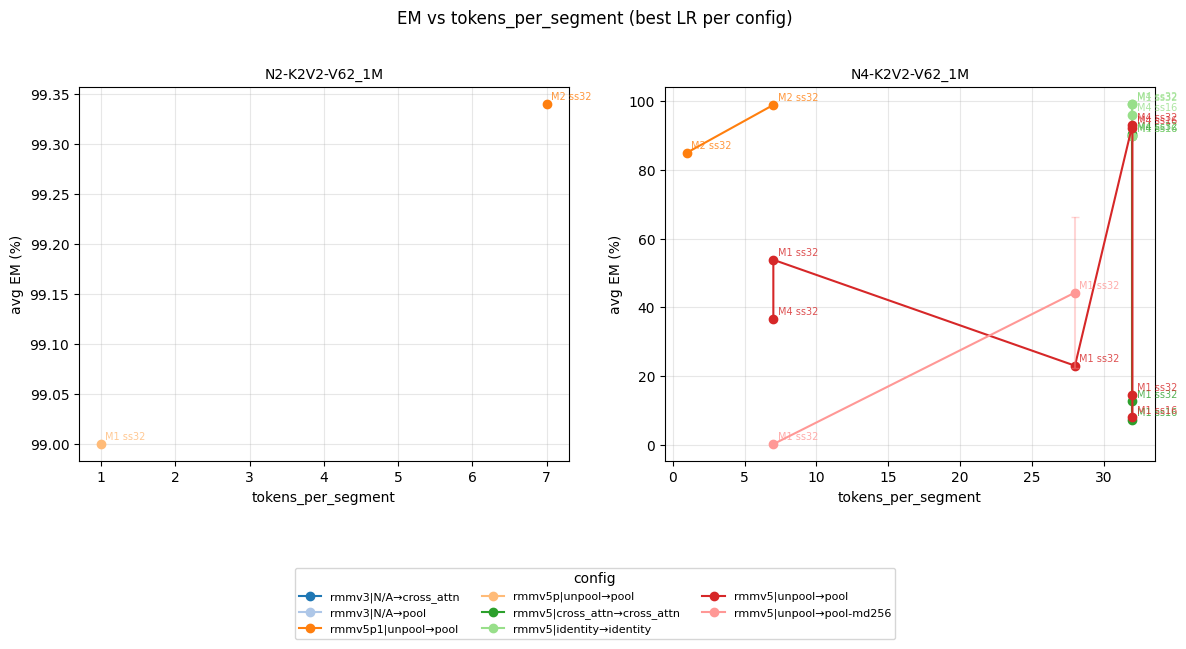

In [ ]:
# ── Plot 1: EM vs tokens_per_segment, facet by task, colour by config_label ─
best_sorted["config_label"] = (
    best_sorted["folder_tag"].astype(str)
    + "|"
    + best_sorted["read_mode"].astype(str)
    + "→"
    + best_sorted["write_config"].astype(str)
)

g = best_sorted.copy()

tasks        = sorted(g['task_name'].unique(), key=lambda x: int(re.search(r'N(\d+)', x).group(1)))
config_labels = sorted(g['config_label'].unique())
palette       = dict(zip(config_labels, plt.cm.tab20.colors[:len(config_labels)]))

n_cols = len(tasks)
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5), sharey=False)
if n_cols == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    sub = g[g['task_name'] == task].copy()
    sub = sub.sort_values('tokens_per_segment')

    for lbl, grp in sub.groupby('config_label'):
        grp = grp.sort_values('tokens_per_segment')
        c = palette[lbl]
        ax.plot(grp['tokens_per_segment'], grp['avg_em'],
                marker='o', color=c, label=lbl, linewidth=1.5)
        ax.errorbar(grp['tokens_per_segment'], grp['avg_em'],
                    yerr=grp['std_em'], fmt='none', color=c, alpha=0.4, capsize=3)
        for _, row in grp.iterrows():
            ax.annotate(
                f"M{int(row['num_memory_vectors']) if pd.notna(row['num_memory_vectors']) else '?'}"
                f" ss{int(row['state_size']) if pd.notna(row['state_size']) else '?'}",
                xy=(row['tokens_per_segment'], row['avg_em']),
                xytext=(3, 3), textcoords='offset points',
                fontsize=7, color=c, alpha=0.8,
            )

    ax.set_title(task, fontsize=10)
    ax.set_xlabel('tokens_per_segment')
    ax.set_ylabel('avg EM (%)')
    ax.grid(True, alpha=0.3)

handles = [plt.Line2D([0], [0], color=palette[l], marker='o', label=l) for l in config_labels]
fig.legend(handles=handles, title='config', loc='lower center',
           bbox_to_anchor=(0.5, -0.25), ncol=3, fontsize=8)
fig.suptitle('EM vs tokens_per_segment (best LR per config)', y=1.02)
fig.tight_layout()
plt.savefig('images/rmmv5_em_vs_tps.png', dpi=150, bbox_inches='tight')
plt.show()

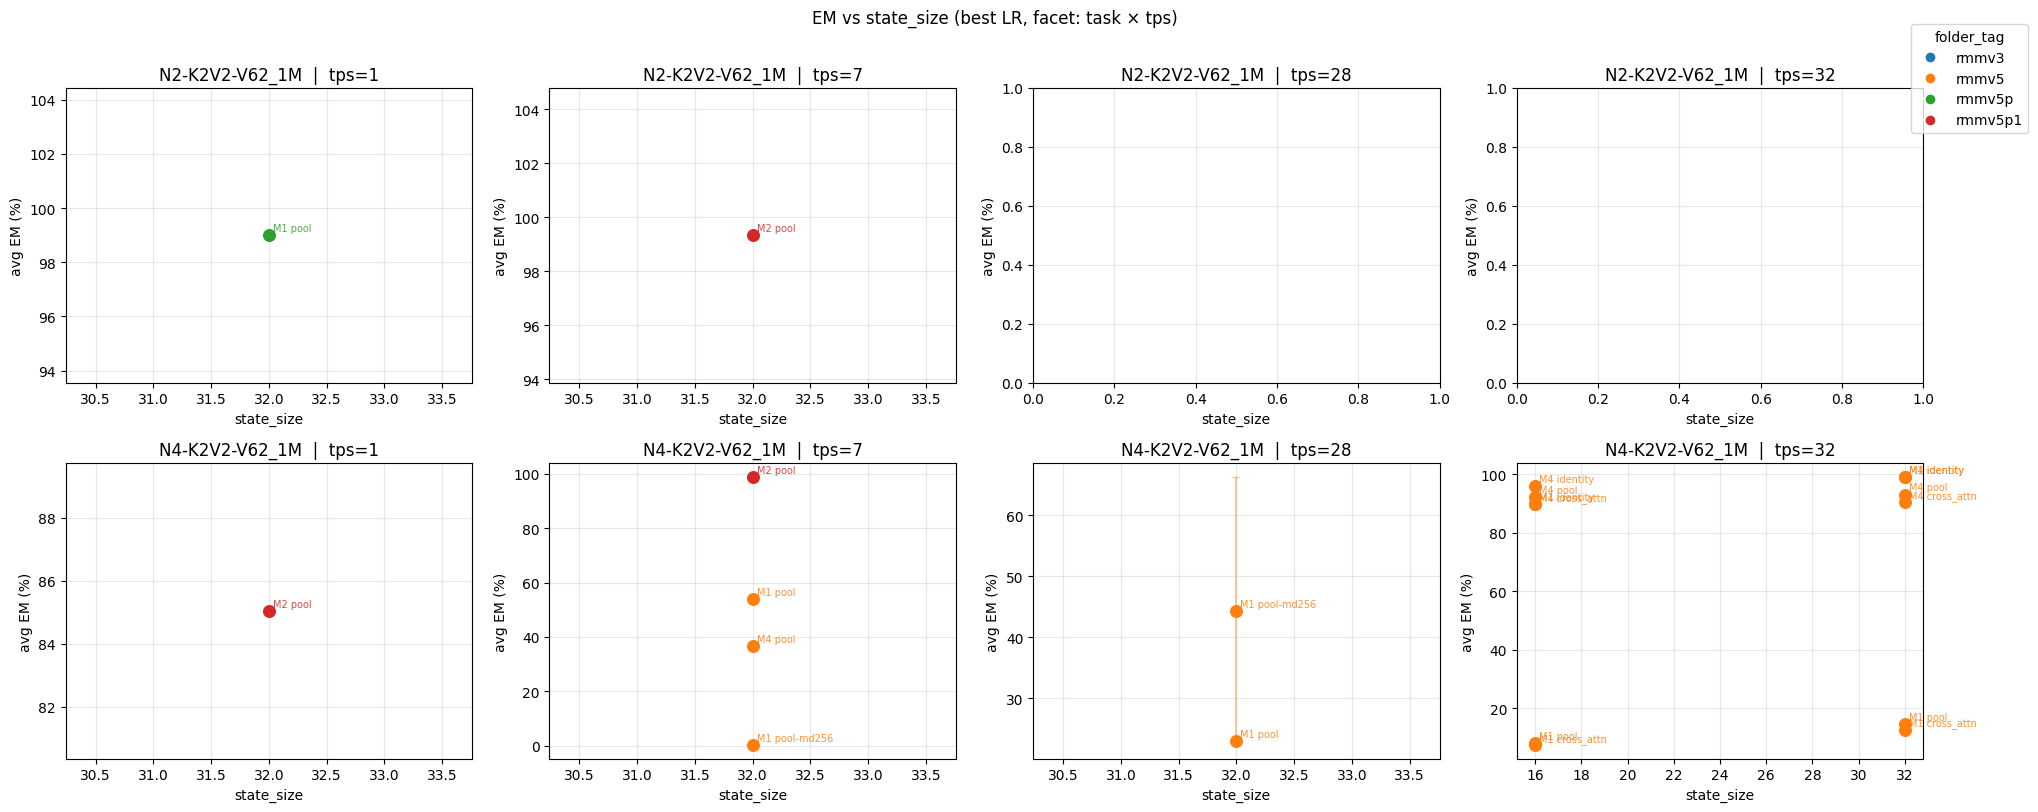

In [ ]:
# ── Plot 2: EM vs state_size, facet by task × tokens_per_segment, colour by folder_tag ─

g = best_sorted.dropna(subset=['state_size']).copy()
g['state_size'] = g['state_size'].astype(int)

tasks   = sorted(g['task_name'].unique(), key=lambda x: int(re.search(r'N(\d+)', x).group(1)))
tps_vals = sorted(g['tokens_per_segment'].dropna().unique())
tags    = sorted(g['folder_tag'].unique())
palette = dict(zip(tags, plt.cm.tab10.colors[:len(tags)]))

n_rows = len(tasks)
n_cols = max(len(tps_vals), 1)
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(5 * n_cols, 4 * n_rows),
                          sharey=False, sharex=False, squeeze=False)

for ri, task in enumerate(tasks):
    for ci, tps in enumerate(tps_vals):
        ax = axes[ri][ci]
        sub = g[(g['task_name'] == task) & (g['tokens_per_segment'] == tps)]

        for tag, grp in sub.groupby('folder_tag'):
            c = palette[tag]
            for _, row in grp.iterrows():
                ax.scatter(row['state_size'], row['avg_em'], color=c, s=70, zorder=3)
                ax.annotate(
                    f"M{int(row['num_memory_vectors']) if pd.notna(row['num_memory_vectors']) else '?'}"
                    f" {row['write_config']}",
                    xy=(row['state_size'], row['avg_em']),
                    xytext=(3, 3), textcoords='offset points',
                    fontsize=7, color=c, alpha=0.85,
                )
            ax.errorbar(grp['state_size'], grp['avg_em'],
                        yerr=grp['std_em'], fmt='none', color=c, alpha=0.4, capsize=3)

        ax.set_title(f'{task}  |  tps={int(tps) if pd.notna(tps) else "?"}')
        ax.set_xlabel('state_size')
        ax.set_ylabel('avg EM (%)')
        ax.grid(True, alpha=0.3)

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=palette[t],
                       markersize=8, label=t) for t in tags]
fig.legend(handles=handles, title='folder_tag', loc='upper right', bbox_to_anchor=(1.02, 1.0))
fig.suptitle('EM vs state_size (best LR, facet: task × tps)', y=1.01)
fig.tight_layout()
plt.savefig('images/rmmv5_em_vs_ss.png', dpi=150, bbox_inches='tight')
plt.show()

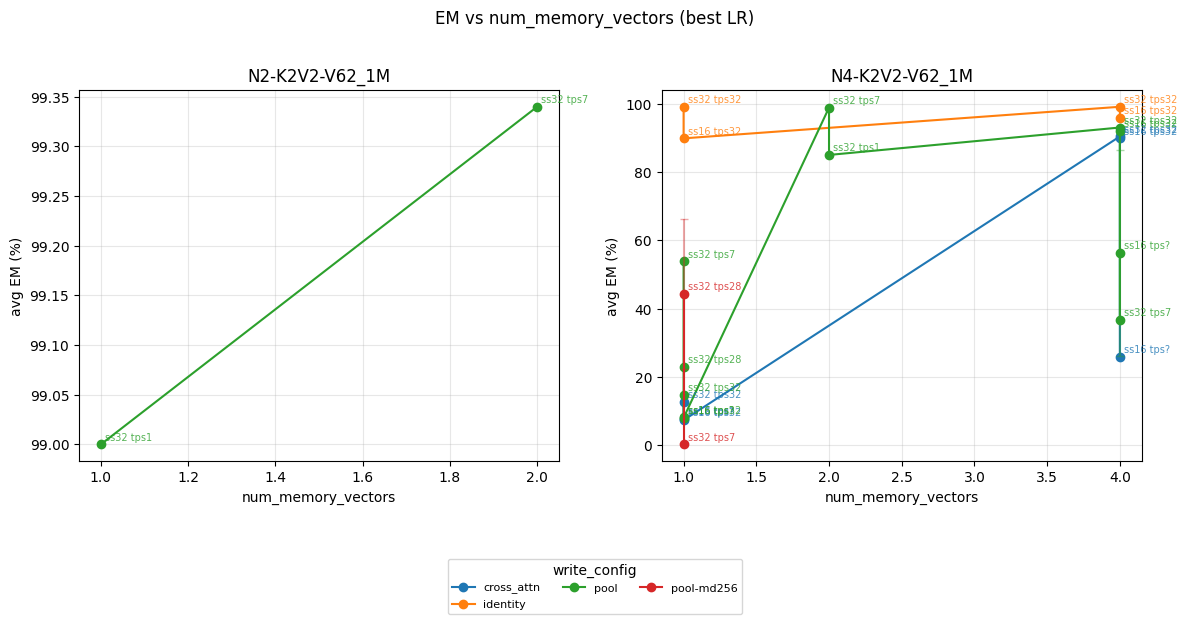

In [ ]:
# ── Plot 3: EM vs num_memory_vectors, facet by task, colour by write_config ─

g = best_sorted.dropna(subset=['num_memory_vectors']).copy()
g['num_memory_vectors'] = g['num_memory_vectors'].astype(int)

tasks   = sorted(g['task_name'].unique(), key=lambda x: int(re.search(r'N(\d+)', x).group(1)))
wcfgs   = sorted(g['write_config'].unique())
palette = dict(zip(wcfgs, plt.cm.tab10.colors[:len(wcfgs)]))

n_cols = len(tasks)
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5), sharey=False, squeeze=False)

for ci, task in enumerate(tasks):
    ax = axes[0][ci]
    sub = g[g['task_name'] == task]

    for wcfg, grp in sub.groupby('write_config'):
        grp = grp.sort_values('num_memory_vectors')
        c = palette[wcfg]
        ax.plot(grp['num_memory_vectors'], grp['avg_em'],
                marker='o', color=c, label=wcfg, linewidth=1.5)
        ax.errorbar(grp['num_memory_vectors'], grp['avg_em'],
                    yerr=grp['std_em'], fmt='none', color=c, alpha=0.4, capsize=3)
        for _, row in grp.iterrows():
            ax.annotate(
                f"ss{int(row['state_size']) if pd.notna(row['state_size']) else '?'}"
                f" tps{int(row['tokens_per_segment']) if pd.notna(row['tokens_per_segment']) else '?'}",
                xy=(row['num_memory_vectors'], row['avg_em']),
                xytext=(3, 3), textcoords='offset points',
                fontsize=7, color=c, alpha=0.8,
            )

    ax.set_title(task)
    ax.set_xlabel('num_memory_vectors')
    ax.set_ylabel('avg EM (%)')
    ax.grid(True, alpha=0.3)

handles = [plt.Line2D([0],[0], color=palette[w], marker='o', label=w) for w in wcfgs]
fig.legend(handles=handles, title='write_config', loc='lower center',
           bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=8)
fig.suptitle('EM vs num_memory_vectors (best LR)', y=1.02)
fig.tight_layout()
plt.savefig('images/rmmv5_em_vs_M.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Plot 4: LR sensitivity – all LRs shown, facet by task, colour by config_label ─

# grouped has GROUP_COLS as MultiIndex; reset to get regular columns
g = grouped.reset_index()
g['config_label'] = (
    g['folder_tag'].astype(str) + '|' +
    g['read_mode'].astype(str) + '→' +
    g['write_config'].astype(str)
)

tasks         = sorted(g['task_name'].unique(), key=lambda x: int(re.search(r'N(\d+)', x).group(1)))
config_labels = sorted(g['config_label'].unique())
palette       = dict(zip(config_labels, plt.cm.tab20.colors[:len(config_labels)]))

n_cols = len(tasks)
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5), sharey=False, squeeze=False)

for ci, task in enumerate(tasks):
    ax = axes[0][ci]
    sub = g[g['task_name'] == task].copy()
    sub['lr_log'] = np.log10(sub['learning_rate'].astype(float))
    sub = sub.sort_values('lr_log')

    for lbl, grp in sub.groupby('config_label'):
        grp = grp.sort_values('lr_log')
        c = palette[lbl]
        ax.plot(grp['lr_log'], grp['avg_em'],
                marker='o', color=c, label=lbl, linewidth=1.5)
        ax.errorbar(grp['lr_log'], grp['avg_em'],
                    yerr=grp['std_em'], fmt='none', color=c, alpha=0.4, capsize=3)

    ax.set_title(task)
    ax.set_xlabel('log10(learning_rate)')
    ax.set_ylabel('avg EM (%)')
    ax.grid(True, alpha=0.3)

handles = [plt.Line2D([0],[0], color=palette[l], marker='o', label=l) for l in config_labels]
fig.legend(handles=handles, title='config', loc='lower center',
           bbox_to_anchor=(0.5, -0.3), ncol=3, fontsize=7)
fig.suptitle('LR sensitivity (all runs)', y=1.02)
fig.tight_layout()
plt.savefig('images/rmmv5_lr_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Plot 5: Heatmap – write_config × tokens_per_segment for each task ───────

for task in sorted(df_valid['task_name'].unique(),
                   key=lambda x: int(re.search(r'N(\d+)', x).group(1))):
    sub = best_sorted[best_sorted['task_name'] == task].copy()
    sub['tps_str'] = sub['tokens_per_segment'].apply(
        lambda x: str(int(x)) if pd.notna(x) else '?'
    )

    try:
        pivot = sub.pivot_table(
            index='write_config',
            columns='tps_str',
            values='avg_em',
            aggfunc='max'
        )
    except Exception:
        continue

    if pivot.empty:
        continue

    fig, ax = plt.subplots(figsize=(max(4, len(pivot.columns) * 1.4), max(3, len(pivot) * 0.8)))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                vmin=0, vmax=100, ax=ax, linewidths=0.5)
    ax.set_title(f'{task}  –  max avg EM (%) by write_config × tps')
    ax.set_xlabel('tokens_per_segment')
    ax.set_ylabel('write_config')
    fig.tight_layout()
    plt.savefig(f'images/rmmv5_heatmap_{task}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# np.random.seed(seed)
num_kv_pairs = 4
num_passes = 1
vocab_size=64
num_examples=100

# two tokens for key and value
context_size = num_kv_pairs * 2 * num_passes

# create keys so that each key is present exactly once in each example
key_vocab_size = vocab_size // 2
key_choices = np.arange(1, key_vocab_size)
value_choices = np.arange(key_vocab_size, vocab_size)

keys_unshuffled = np.tile(key_choices, (num_examples, 1))
keys = np.apply_along_axis(np.random.choice, 1, keys_unshuffled, replace=False, size=num_kv_pairs)

values_unshuffled = np.tile(value_choices, (num_examples, 1))
values = np.apply_along_axis(np.random.choice, 1, values_unshuffled, replace=False, size=num_kv_pairs)

# create sequences
kvs = np.zeros((num_examples, context_size), dtype=np.int64)
kvs[:, 0::2] = keys
kvs[:, 1::2] = values
kvs = np.tile(kvs, (1, num_passes))


In [ ]:
kvs

array([[23, 35,  7, 34,  6, 63,  9, 42],
       [26, 39,  4, 32,  2, 58, 29, 49],
       [ 3, 52,  6, 37, 27, 54,  5, 47],
       [20, 62, 28, 37, 21, 59, 12, 54],
       [12, 36, 20, 34, 22, 49, 19, 48],
       [18, 41, 14, 42,  1, 44, 24, 62],
       [ 4, 37, 21, 61, 17, 36, 13, 55],
       [11, 63,  8, 49,  2, 40, 18, 62],
       [ 5, 57, 27, 62, 26, 58,  3, 47],
       [19, 41, 17, 34, 26, 55, 15, 42],
       [ 1, 55,  3, 63,  5, 37, 19, 48],
       [31, 51, 30, 57, 19, 33, 11, 36],
       [31, 49,  9, 32, 27, 56, 22, 53],
       [11, 60, 16, 61, 26, 58, 19, 62],
       [18, 58, 11, 53,  2, 46, 12, 42],
       [ 2, 54, 13, 41, 15, 37, 25, 42],
       [16, 44, 23, 38, 26, 55,  5, 45],
       [20, 62, 15, 41,  9, 50, 28, 61],
       [31, 52,  6, 55,  5, 53, 10, 37],
       [20, 38, 16, 36, 19, 42,  3, 60],
       [14, 37, 11, 35, 24, 45, 16, 54],
       [ 1, 34,  6, 63, 31, 47, 16, 57],
       [10, 55, 19, 38, 25, 53, 13, 49],
       [23, 59,  3, 44, 31, 47,  8, 54],
       [25, 51, 

In [ ]:
values_unshuffled

array([[32, 33, 34, ..., 61, 62, 63],
       [32, 33, 34, ..., 61, 62, 63],
       [32, 33, 34, ..., 61, 62, 63],
       ...,
       [32, 33, 34, ..., 61, 62, 63],
       [32, 33, 34, ..., 61, 62, 63],
       [32, 33, 34, ..., 61, 62, 63]], shape=(100, 32))